# Notebook 04 — Skeleton Baselines (BiLSTM + 1D-CNN)

**Milestone 2, Step 4**

Trains two skeleton-based baselines on the clean signer-dependent (SD) split.
Results establish the lower bounds that ST-GCN must beat in Milestone 3.

| Model | Input | Key layers |
|---|---|---|
| BiLSTM | `(T, 159)` flattened sequence | 2-layer bidirectional LSTM → Linear |
| 1D-CNN | `(T, 159)` flattened sequence | 3× Conv1D + BN → GlobalAvgPool → Linear |

Input: T=64 frames × 53 joints × 3 coords = 159 features per frame.

### Evaluation protocols
- **SD (Signer-Dependent) — main benchmark:** Official INCLUDE train/val/test split, fully
  deduplicated (cross-split and within-split). Early stopping on `val`; final numbers on held-out `test`.
- **Recording-session proxy (SI section below) — supplementary only:** 5-fold CV using
  proxy signer IDs (rank by MVI filename). Signer labels are not publicly available in INCLUDE.
  These results **must not be reported as cross-signer generalisation** (supervisor decision, June 2026).

### Normalization
Torso-centred per sample (each video normalised using its own shoulder midpoint and width).
No dataset-level statistics are fitted — zero train→test leakage.

### Reproducibility
All runs seeded with `SEED = 42` (see seed cell below).

In [1]:
%pip install torch numpy scikit-learn matplotlib tqdm --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from tqdm.notebook import trange, tqdm
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/yamini/Desktop/projects/ISL PROJECT")
PROC_DIR     = PROJECT_ROOT / "data" / "processed"

# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 40
PATIENCE     = 8         # early stopping — stop if val loss doesn't improve
DROPOUT      = 0.3
HIDDEN_DIM   = 256       # LSTM hidden size

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.8.0


In [3]:
# ── Reproducibility ──────────────────────────────────────────────────────────
import random, os

SEED = 42
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Seed fixed: {SEED}")

Seed fixed: 42


In [4]:
# ── Load preprocessed SD splits ──────────────────────────────────────────────
X_train = np.load(str(PROC_DIR / "X_sd_train.npy"))  # (N, 64, 53, 3)
y_train = np.load(str(PROC_DIR / "y_sd_train.npy"))  # (N,)
X_val   = np.load(str(PROC_DIR / "X_sd_val.npy"))
y_val   = np.load(str(PROC_DIR / "y_sd_val.npy"))
X_test  = np.load(str(PROC_DIR / "X_sd_test.npy"))
y_test  = np.load(str(PROC_DIR / "y_sd_test.npy"))

N_CLASSES = int(y_train.max()) + 1
T, J, C   = X_train.shape[1], X_train.shape[2], X_train.shape[3]
FEAT_DIM  = J * C   # 53 * 3 = 159

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"T={T}, joints={J}, coords={C} → feature dim={FEAT_DIM}")
print(f"Classes: {N_CLASSES}")

# Flatten spatial dims: (N, T, 53, 3) → (N, T, 159)
X_train_flat = X_train.reshape(X_train.shape[0], T, FEAT_DIM)
X_val_flat   = X_val.reshape(X_val.shape[0],   T, FEAT_DIM)
X_test_flat  = X_test.reshape(X_test.shape[0],  T, FEAT_DIM)

Train: (3121, 64, 53, 3)  Val: (347, 64, 53, 3)  Test: (816, 64, 53, 3)
T=64, joints=53, coords=3 → feature dim=159
Classes: 262


In [5]:
class SkeletonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = SkeletonDataset(X_train_flat, y_train)
val_ds   = SkeletonDataset(X_val_flat,   y_val)
test_ds  = SkeletonDataset(X_test_flat,  y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"DataLoaders ready. Batches per epoch: {len(train_dl)}")

DataLoaders ready. Batches per epoch: 98


In [6]:
# ── Model 1: Bidirectional LSTM ──────────────────────────────────────────────
class BiLSTM(nn.Module):
    """
    2-layer bidirectional LSTM for sequence classification.
    Input : (batch, T, feat_dim)
    Output: (batch, n_classes) logits
    """
    def __init__(self, feat_dim, hidden_dim, n_classes, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feat_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim * 2, n_classes)   # ×2 for bidirectional

    def forward(self, x):
        out, (h, _) = self.lstm(x)
        # Concatenate last hidden state from both directions
        h_fwd = h[-2]   # forward  last layer
        h_bwd = h[-1]   # backward last layer
        h_cat = torch.cat([h_fwd, h_bwd], dim=1)
        return self.fc(self.drop(h_cat))

# ── Model 2: 1D-CNN ──────────────────────────────────────────────────────────
class CNN1D(nn.Module):
    """
    3-layer 1D ConvNet for sequence classification.
    Input : (batch, T, feat_dim)
    Output: (batch, n_classes) logits
    """
    def __init__(self, feat_dim, n_classes, dropout=0.3):
        super().__init__()
        # Conv1d expects (batch, channels, length) — we treat feat_dim as channels
        self.net = nn.Sequential(
            nn.Conv1d(feat_dim, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),   # (batch, 256, 1)
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(256, n_classes)

    def forward(self, x):
        # x: (batch, T, feat_dim) → (batch, feat_dim, T)
        x = x.permute(0, 2, 1)
        x = self.net(x).squeeze(-1)   # (batch, 256)
        return self.fc(self.drop(x))

print("Model classes defined.")
print(f"BiLSTM params : {sum(p.numel() for p in BiLSTM(FEAT_DIM, HIDDEN_DIM, N_CLASSES).parameters()):,}")
print(f"CNN1D  params : {sum(p.numel() for p in CNN1D(FEAT_DIM, N_CLASSES).parameters()):,}")

Model classes defined.
BiLSTM params : 2,565,382
CNN1D  params : 222,086


In [7]:
def train_model(model, train_dl, val_dl, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    """Train model with early stopping. Returns (trained_model, history_dict)."""
    model = model.to(DEVICE)
    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
    criterion  = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state    = None
    no_improve    = 0
    history       = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in trange(epochs, desc="Training"):
        # ── Train ──────────────────────────────────────────────────────────
        model.train()
        running_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss   = criterion(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item() * len(yb)
        train_loss = running_loss / len(train_dl.dataset)

        # ── Validate ───────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * len(yb)
                preds = logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
        val_loss /= len(val_dl.dataset)
        val_acc   = accuracy_score(all_labels, all_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at epoch {epoch + 1} (best val_loss={best_val_loss:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history


def evaluate(model, dl):
    """Returns top-1 accuracy and macro F1 on a DataLoader."""
    model.eval().to(DEVICE)
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in dl:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    top1 = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return top1, f1

print("train_model and evaluate functions ready.")

train_model and evaluate functions ready.


In [8]:
# ── Train BiLSTM ─────────────────────────────────────────────────────────────
print("=" * 50)
print("Training BiLSTM baseline...")
print("=" * 50)

lstm_model   = BiLSTM(FEAT_DIM, HIDDEN_DIM, N_CLASSES, dropout=DROPOUT)
lstm_model, lstm_history = train_model(lstm_model, train_dl, val_dl)

lstm_val_top1,  lstm_val_f1  = evaluate(lstm_model, val_dl)
lstm_test_top1, lstm_test_f1 = evaluate(lstm_model, test_dl)

print(f"\nBiLSTM — Val  : top-1={lstm_val_top1:.3f}, macro-F1={lstm_val_f1:.3f}")
print(f"BiLSTM — Test : top-1={lstm_test_top1:.3f}, macro-F1={lstm_test_f1:.3f}")

torch.save(lstm_model.state_dict(), str(PROC_DIR / "bilstm_best.pt"))
print("BiLSTM weights saved.")

Training BiLSTM baseline...


Training:   0%|          | 0/40 [00:00<?, ?it/s]


BiLSTM — Val  : top-1=0.602, macro-F1=0.545
BiLSTM — Test : top-1=0.630, macro-F1=0.605
BiLSTM weights saved.


In [9]:
# ── Train 1D-CNN ─────────────────────────────────────────────────────────────
print("=" * 50)
print("Training 1D-CNN baseline...")
print("=" * 50)

cnn_model   = CNN1D(FEAT_DIM, N_CLASSES, dropout=DROPOUT)
cnn_model, cnn_history = train_model(cnn_model, train_dl, val_dl)

cnn_val_top1,  cnn_val_f1  = evaluate(cnn_model, val_dl)
cnn_test_top1, cnn_test_f1 = evaluate(cnn_model, test_dl)

print(f"\n1D-CNN — Val  : top-1={cnn_val_top1:.3f}, macro-F1={cnn_val_f1:.3f}")
print(f"1D-CNN — Test : top-1={cnn_test_top1:.3f}, macro-F1={cnn_test_f1:.3f}")

torch.save(cnn_model.state_dict(), str(PROC_DIR / "cnn1d_best.pt"))
print("1D-CNN weights saved.")

Training 1D-CNN baseline...


Training:   0%|          | 0/40 [00:00<?, ?it/s]


1D-CNN — Val  : top-1=0.922, macro-F1=0.902
1D-CNN — Test : top-1=0.909, macro-F1=0.907
1D-CNN weights saved.


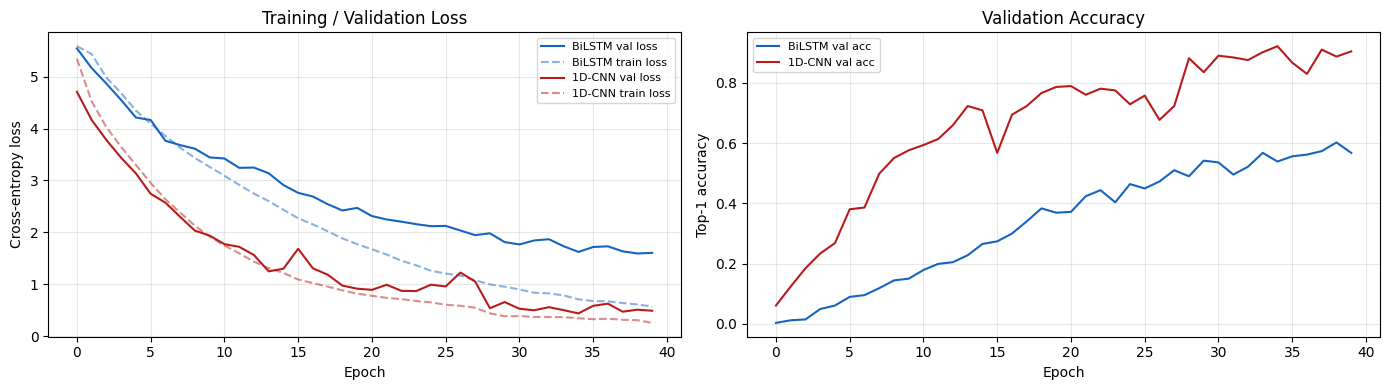

In [10]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, history, label, color in [
    (axes[0], lstm_history, "BiLSTM", "#1565C0"),
    (axes[0], cnn_history,  "1D-CNN", "#B71C1C"),
]:
    ax.plot(history["val_loss"],  label=f"{label} val loss",  color=color, linestyle="-")
    ax.plot(history["train_loss"],label=f"{label} train loss",color=color, linestyle="--", alpha=0.5)
axes[0].set_title("Training / Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for history, label, color in [
    (lstm_history, "BiLSTM", "#1565C0"),
    (cnn_history,  "1D-CNN", "#B71C1C"),
]:
    axes[1].plot(history["val_acc"], label=f"{label} val acc", color=color)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Top-1 accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(PROC_DIR / "baseline_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# ── SD results table ─────────────────────────────────────────────────────────
import pandas as pd

sd_results = pd.DataFrame([
    # Literature references
    {"Method"    : "XGBoost (Sridhar et al. 2020)",
     "Modality"  : "Skeleton",
     "Protocol"  : "SD",
     "Top-1"     : "63.1%",
     "Macro F1"  : "—",
     "Source"    : "INCLUDE paper; skeleton joint angles"},
    {"Method"    : "MobileNetV2+BiLSTM (Sridhar et al. 2020)",
     "Modality"  : "RGB video",
     "Protocol"  : "SD",
     "Top-1"     : "85.6%",
     "Macro F1"  : "—",
     "Source"    : "INCLUDE paper; NOT comparable to skeleton models"},
    {"Method"    : "ST-GCN (Song et al. 2025)",
     "Modality"  : "Skeleton",
     "Protocol"  : "SD",
     "Top-1"     : "99.02%",
     "Macro F1"  : "—",
     "Source"    : "HA-GCN paper Table 2; INCLUDE dataset"},
    {"Method"    : "HA-GCN multi-stream (Song et al. 2025)",
     "Modality"  : "Skeleton",
     "Protocol"  : "SD",
     "Top-1"     : "99.63%",
     "Macro F1"  : "—",
     "Source"    : "HA-GCN paper Table 2; INCLUDE dataset; SI not reported"},
    # Our results — SD
    {"Method"    : "BiLSTM on skeleton (ours)",
     "Modality"  : "Skeleton",
     "Protocol"  : "SD",
     "Top-1"     : f"{lstm_test_top1:.1%}",
     "Macro F1"  : f"{lstm_test_f1:.3f}",
     "Source"    : f"53-joint MediaPipe, T={T}, hidden={HIDDEN_DIM}"},
    {"Method"    : "1D-CNN on skeleton (ours)",
     "Modality"  : "Skeleton",
     "Protocol"  : "SD",
     "Top-1"     : f"{cnn_test_top1:.1%}",
     "Macro F1"  : f"{cnn_test_f1:.3f}",
     "Source"    : f"53-joint MediaPipe, T={T}, 3×Conv1D"},
])

print("=== SD Results ===")
print(sd_results.to_string(index=False))
sd_results.to_csv(str(PROC_DIR / "baseline_results.csv"), index=False)
print("\nSaved to baseline_results.csv")


=== SD Results ===
                                  Method  Modality Protocol  Top-1 Macro F1                                                 Source
           XGBoost (Sridhar et al. 2020)  Skeleton       SD  63.1%        —                   INCLUDE paper; skeleton joint angles
MobileNetV2+BiLSTM (Sridhar et al. 2020) RGB video       SD  85.6%        —       INCLUDE paper; NOT comparable to skeleton models
               ST-GCN (Song et al. 2025)  Skeleton       SD 99.02%        —                  HA-GCN paper Table 2; INCLUDE dataset
  HA-GCN multi-stream (Song et al. 2025)  Skeleton       SD 99.63%        — HA-GCN paper Table 2; INCLUDE dataset; SI not reported
               BiLSTM on skeleton (ours)  Skeleton       SD  63.0%    0.605                   53-joint MediaPipe, T=64, hidden=256
               1D-CNN on skeleton (ours)  Skeleton       SD  90.9%    0.907                     53-joint MediaPipe, T=64, 3×Conv1D

Saved to baseline_results.csv


In [12]:
# ── SI evaluation — ⚠ PROVISIONAL (proxy signer IDs) ─────────────────────────
#
# Signer IDs were assigned by ranking videos within each sign class by MVI
# filename (rank % 15).  The INCLUDE parquet does not ship real signer labels.
# The uneven per-group counts (387 → 125 vs. ~243 expected) confirm these
# groups do NOT correspond to real individuals.
#
# These results are computed for completeness and to establish a code baseline,
# but they must NOT be reported as cross-signer generalisation.
# Re-run after real signer IDs are confirmed.

print("=" * 60)
print("SI evaluation — 5-fold CV  (⚠ PROVISIONAL — proxy signer IDs)")
print("=" * 60)

with open(str(PROC_DIR / "si_splits.pkl"), "rb") as f:
    si_splits = pickle.load(f)

lstm_si_top1, lstm_si_f1 = [], []
cnn_si_top1,  cnn_si_f1  = [], []

for fold_dict in si_splits:
    fold = fold_dict["fold"]
    print(f"\n--- Fold {fold} (proxy-group: {fold_dict['held_out']}) ---")

    Xtr = fold_dict["X_train"].reshape(len(fold_dict["X_train"]), T, FEAT_DIM)
    ytr = fold_dict["y_train"]
    Xte = fold_dict["X_test"].reshape(len(fold_dict["X_test"]),  T, FEAT_DIM)
    yte = fold_dict["y_test"]

    n_val_si = max(1, int(0.10 * len(Xtr)))
    idx = np.random.RandomState(42).permutation(len(Xtr))
    Xtr_si = Xtr[idx[n_val_si:]];  ytr_si = ytr[idx[n_val_si:]]
    Xva_si = Xtr[idx[:n_val_si]];  yva_si = ytr[idx[:n_val_si]]

    fold_train_dl = DataLoader(SkeletonDataset(Xtr_si, ytr_si),
                               batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    fold_val_dl   = DataLoader(SkeletonDataset(Xva_si, yva_si),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    fold_test_dl  = DataLoader(SkeletonDataset(Xte, yte),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    m_lstm = BiLSTM(FEAT_DIM, HIDDEN_DIM, N_CLASSES, dropout=DROPOUT)
    m_lstm, _ = train_model(m_lstm, fold_train_dl, fold_val_dl)
    t1, f1 = evaluate(m_lstm, fold_test_dl)
    lstm_si_top1.append(t1); lstm_si_f1.append(f1)
    print(f"  BiLSTM  top-1={t1:.3f}  macro-F1={f1:.3f}")

    m_cnn = CNN1D(FEAT_DIM, N_CLASSES, dropout=DROPOUT)
    m_cnn, _ = train_model(m_cnn, fold_train_dl, fold_val_dl)
    t1, f1 = evaluate(m_cnn, fold_test_dl)
    cnn_si_top1.append(t1); cnn_si_f1.append(f1)
    print(f"  1D-CNN  top-1={t1:.3f}  macro-F1={f1:.3f}")

print("\n=== SI Summary (mean ± std, 5 folds) — PROVISIONAL ===")
print(f"BiLSTM  top-1 : {np.mean(lstm_si_top1):.3f} ± {np.std(lstm_si_top1):.3f}  "
      f"macro-F1: {np.mean(lstm_si_f1):.3f} ± {np.std(lstm_si_f1):.3f}")
print(f"1D-CNN  top-1 : {np.mean(cnn_si_top1):.3f} ± {np.std(cnn_si_top1):.3f}  "
      f"macro-F1: {np.mean(cnn_si_f1):.3f} ± {np.std(cnn_si_f1):.3f}")

import pandas as pd
si_results = pd.DataFrame([
    {"Method"   : "BiLSTM on skeleton (ours)",
     "Modality" : "Skeleton",
     "Protocol" : "SI-proxy (5-fold)",
     "Top-1"    : f"{np.mean(lstm_si_top1):.1%} ± {np.std(lstm_si_top1):.1%}",
     "Macro F1" : f"{np.mean(lstm_si_f1):.3f} ± {np.std(lstm_si_f1):.3f}",
     "Source"   : "PROVISIONAL — proxy signer IDs, not real cross-signer split"},
    {"Method"   : "1D-CNN on skeleton (ours)",
     "Modality" : "Skeleton",
     "Protocol" : "SI-proxy (5-fold)",
     "Top-1"    : f"{np.mean(cnn_si_top1):.1%} ± {np.std(cnn_si_top1):.1%}",
     "Macro F1" : f"{np.mean(cnn_si_f1):.3f} ± {np.std(cnn_si_f1):.3f}",
     "Source"   : "PROVISIONAL — proxy signer IDs, not real cross-signer split"},
])
print(si_results.to_string(index=False))
si_results.to_csv(str(PROC_DIR / "baseline_results_si.csv"), index=False)
print("\nSaved to baseline_results_si.csv  (PROVISIONAL)")

SI evaluation — 5-fold CV  (⚠ PROVISIONAL — proxy signer IDs)



--- Fold 0 (proxy-group: [0, 1, 2]) ---


Training:   0%|          | 0/40 [00:00<?, ?it/s]

  BiLSTM  top-1=0.413  macro-F1=0.374


Training:   0%|          | 0/40 [00:00<?, ?it/s]

...

  1D-CNN  top-1=0.848  macro-F1=0.826

--- Fold 4 (proxy-group: [12, 13, 14]) ---


Training:   0%|          | 0/40 [00:00<?, ?it/s]

  BiLSTM  top-1=0.481  macro-F1=0.439


Training:   0%|          | 0/40 [00:00<?, ?it/s]

  1D-CNN  top-1=0.764  macro-F1=0.735

=== SI Summary (mean ± std, 5 folds) — PROVISIONAL ===
BiLSTM  top-1 : 0.491 ± 0.055  macro-F1: 0.453 ± 0.048
1D-CNN  top-1 : 0.770 ± 0.051  macro-F1: 0.748 ± 0.050
                   Method Modality          Protocol        Top-1      Macro F1                                                      Source
BiLSTM on skeleton (ours) Skeleton SI-proxy (5-fold) 49.1% ± 5.5% 0.453 ± 0.048 PROVISIONAL — proxy signer IDs, not real cross-signer split
1D-CNN on skeleton (ours) Skeleton SI-proxy (5-fold) 77.0% ± 5.1% 0.748 ± 0.050 PROVISIONAL — proxy signer IDs, not real cross-signer split

Saved to baseline_results_si.csv  (PROVISIONAL)
